# Baseline Model

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/real-estate-cleaned.csv")
df.head()

,List Year,Date Recorded,Town,Assessed Value,Sale Amount,Property Type,Residential Type,Location
0,2010,10/02/2010,Norwalk,339640.0,265000.0,Residential,Single Family,POINT (-73.408 41.118)
1,2010,10/03/2010,Milford,674350.0,788000.0,Residential,Single Family,POINT (-73.057 41.222)
2,2010,10/04/2010,Bridgeport,132250.0,148000.0,Residential,Single Family,POINT (-73.195 41.186)
3,2010,10/04/2010,Bristol,99610.0,32000.0,Residential,Single Family,POINT (-72.94 41.671)
4,2010,10/04/2010,Bridgeport,132260.0,110000.0,Residential,Single Family,POINT (-73.195 41.186)


In [3]:
print(df.shape)
print(df.columns)

(614534, 8)
Index(['List Year', 'Date Recorded', 'Town', 'Assessed Value', 'Sale Amount',
       'Property Type', 'Residential Type', 'Location'],
      dtype='object')


In [4]:
# check numeric or str
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614534 entries, 0 to 614533
Data columns (total 8 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   List Year         614534 non-null  int64  
 1   Date Recorded     614534 non-null  object 
 2   Town              614534 non-null  object 
 3   Assessed Value    614534 non-null  float64
 4   Sale Amount       614534 non-null  float64
 5   Property Type     614534 non-null  object 
 6   Residential Type  594099 non-null  object 
 7   Location          614534 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 37.5+ MB


List Year               0
Date Recorded           0
Town                    0
Assessed Value          0
Sale Amount             0
Property Type           0
Residential Type    20435
Location                0
dtype: int64

In [5]:
# drop rows
df = df.dropna(subset=["Town", "Property Type", "Residential Type", "Assessed Value", "Sale Amount"])

In [6]:
# define target features
X = df[["List Year", "Town", "Assessed Value", "Property Type", "Residential Type"]]
y = df["Sale Amount"]

In [7]:
print("rows after cleaning:", df.shape[0])
print("features used:", X.columns.tolist())

rows after cleaning: 594099
features used: ['List Year', 'Town', 'Assessed Value', 'Property Type', 'Residential Type']


In [8]:
# train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [9]:
# categorical + numeric cols
categorical_cols = ["Town", "Property Type", "Residential Type"]
numeric_cols = ["List Year", "Assessed Value"]

In [10]:
# build preprocessor w/ transformers
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numeric_cols)
    ]
)

In [11]:
# train baseline model (linear regression as baseline ofc)
model = Pipeline(steps=[("preprocessor", preprocessor), ("regressor", LinearRegression())])
model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [12]:
# eval
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("R^2:", r2)

rmse = np.sqrt(mse)
print("RMSE:", rmse)

MSE: 628889487914.8538
R^2: 0.0427577121217243
RMSE: 793025.5279086883


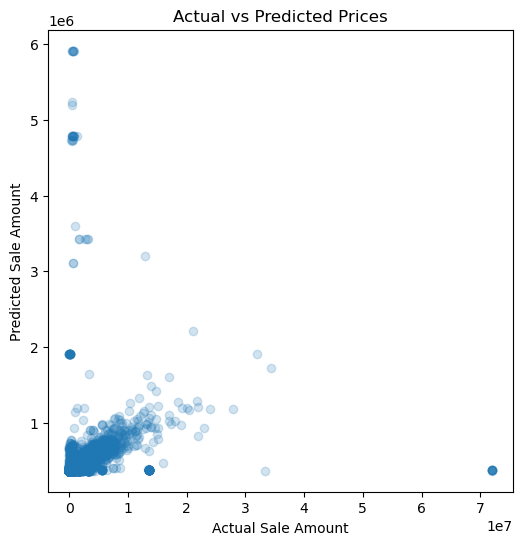

In [13]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.2)
# plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red")
plt.xlabel("Actual Sale Amount")
plt.ylabel("Predicted Sale Amount")
plt.title("Actual vs Predicted Prices")
plt.show()

In [14]:
# just for reference
print("training rows:", X_train.shape[0])
print("testing rows:", X_test.shape[0])

training rows: 415869
testing rows: 178230
